In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [11]:
df['Дата'] = pd.to_datetime(df['Дата'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB


Сгруппируйте данные по дате, посчитайте количество продаж

In [13]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [14]:
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Нарисуйте график продаж у `grouped_df`

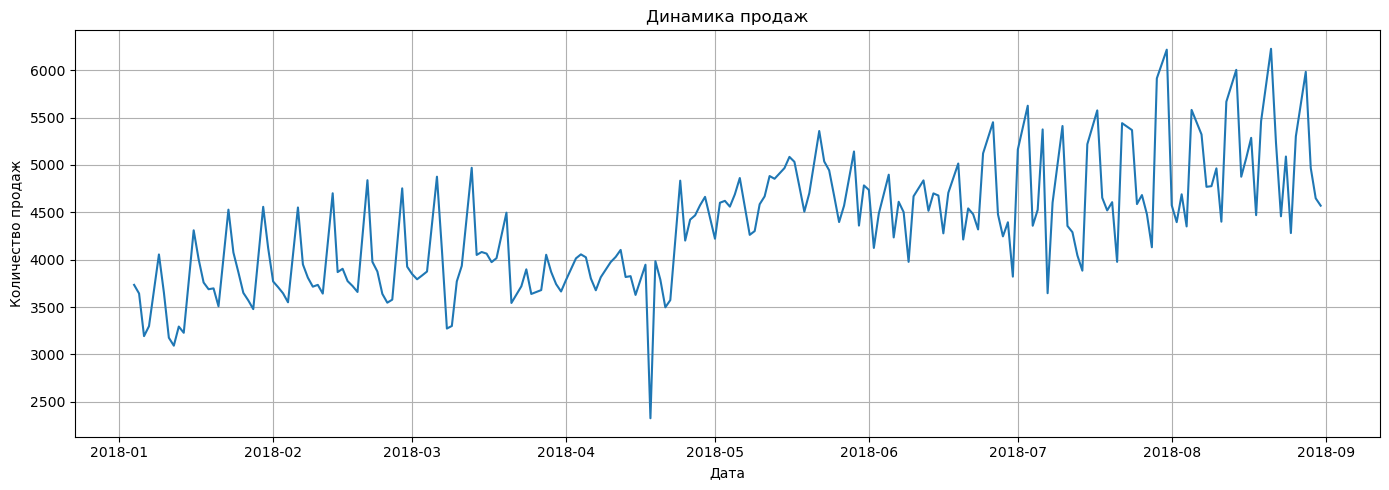

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(grouped_df['Дата'], grouped_df['Количество'])
plt.title('Динамика продаж')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid(True)
plt.tight_layout()
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

**Период:** январь 2018 — сентябрь 2018

**Общий тренд:** наблюдается положительный тренд — 
продажи растут с ~3500-4000 в начале года до ~4500-5500 к августу-сентябрю.

**Сезонность:** прослеживается недельная цикличность — 
регулярные спады, вероятно связанные с выходными днями.

**Выброс:** в конце апреля — начале мая виден резкий аномальный 
спад до ~2500, что значительно ниже среднего уровня. 
Это может быть связано с праздничными днями (майские праздники).

**Максимум:** пиковые значения наблюдаются в августе 2018 — 
продажи достигают 6000+.

**Волатильность:** во второй половине года (июнь-сентябрь) 
колебания между днями становятся более выраженными.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [16]:
min_date = grouped_df.loc[grouped_df['Количество'].idxmin(), 'Дата']
print(min_date)

df[df['Дата'] == min_date]

2018-04-18 00:00:00


,Дата,Склад,Контрагент,Номенклатура,Количество
129472,2018-04-18,1,address_0,product_4,1
129473,2018-04-18,1,address_0,product_5,1
129474,2018-04-18,1,address_0,product_6,2
129475,2018-04-18,1,address_0,product_10,1
129476,2018-04-18,1,address_0,product_11,1
...,...,...,...,...,...
130631,2018-04-18,5,address_174,product_6,5
130632,2018-04-18,5,address_174,product_23,0
130633,2018-04-18,5,address_174,product_12,2
130634,2018-04-18,5,address_174,product_22,4


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [18]:
df['день_недели'] = df['Дата'].dt.dayofweek
df['месяц'] = df['Дата'].dt.month

filtered = df[
    (df['Склад'] == 3) &
    (df['день_недели'] == 2) &
    (df['месяц'].isin([6, 7, 8]))
]

result = filtered.groupby('Номенклатура')['Количество'].sum().sort_values(ascending=False)
print(result.head(1))

Номенклатура
product_1    2267
Name: Количество, dtype: int64


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [30]:
weather = pd.read_csv('35188.01.01.2018.01.09.2018.1.0.0.ru.ansi.00000000.csv', 
                       sep=';', 
                       encoding='cp1251',
                       skiprows=6,
                       on_bad_lines='skip',
                       index_col=False,
                       usecols=[0, 1])

weather.columns = ['Дата', 'T']

weather['Дата'] = pd.to_datetime(weather['Дата'], format='%d.%m.%Y %H:%M')

weather['Дата'] = weather['Дата'].dt.normalize()
weather = weather.groupby('Дата')['T'].mean().reset_index()

print(weather.head())

        Дата        T
0 2018-01-01  -9.4625
1 2018-01-02  -9.5125
2 2018-01-03 -11.4625
3 2018-01-04 -14.0750
4 2018-01-05 -16.8625


In [31]:
merged_df = grouped_df.merge(weather, on='Дата', how='inner')

print(merged_df.head())

        Дата  Количество        T
0 2018-01-04        3734 -14.0750
1 2018-01-05        3643 -16.8625
2 2018-01-06        3193 -13.3000
3 2018-01-07        3298 -12.7500
4 2018-01-09        4055  -6.2500


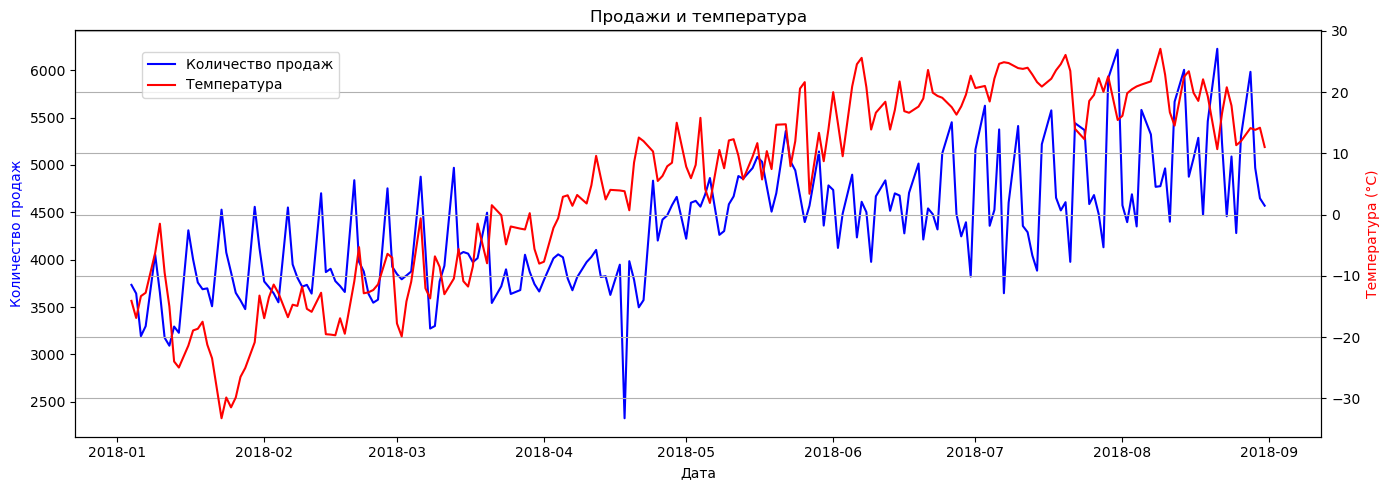

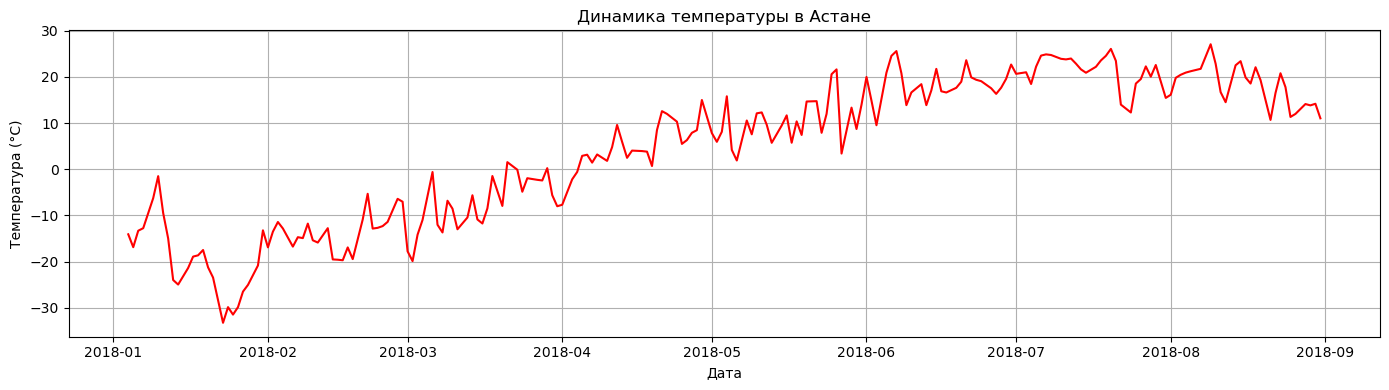

In [32]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(merged_df['Дата'], merged_df['Количество'], color='blue', label='Количество продаж')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество продаж', color='blue')

ax2 = ax1.twinx()
ax2.plot(merged_df['Дата'], merged_df['T'], color='red', label='Температура')
ax2.set_ylabel('Температура (°C)', color='red')

plt.title('Продажи и температура')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(merged_df['Дата'], merged_df['T'], color='red')
plt.title('Динамика температуры в Астане')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.grid(True)
plt.tight_layout()
plt.show()